# Notebook 02 — Modelo de temperatura Alaton

Calibración del modelo Alaton et al. (2002) para temperatura media diaria en Casanare y Tolima.
La temperatura se descompone en componente determinístico estacional + proceso Ornstein–Uhlenbeck.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

SEED = 42                                # reproducibilidad de la simulación
np.random.seed(SEED)

OUT_DIR = Path('../data/processed')
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
df = pd.read_excel('../data/processed/Modelo_Completo.xlsx', parse_dates=['date'])
df = df.set_index('date')

cols = ['t_mean', 't_min', 't_max', 'precip']
df_Casanare = df[df['department'] == 'Casanare'][cols].copy()
df_Tolima   = df[df['department'] == 'Tolima'][cols].copy()

print(f"Casanare: {df_Casanare.shape} | Tolima: {df_Tolima.shape}")
print(df_Tolima.head(3))

Casanare: (5844, 4) | Tolima: (5844, 4)
               t_mean      t_min      t_max  precip
date                                               
2010-01-01  25.247052  19.954775  30.539328    0.72
2010-01-02  25.573658  19.865986  31.281329    0.00
2010-01-03  25.708540  19.791672  31.625407    0.00


## Modelo Alaton et al. (2002)

La temperatura diaria $T_t$ se descompone en un componente determinístico estacional y uno estocástico:

$$T_t = T_t^{\text{est}} + X_t$$

**Componente estacional** — regresión OLS con funciones trigonométricas del día del año $d_t \in [1, 365]$:

$$T_t^{\text{est}} = A + a\sin\!\left(\tfrac{2\pi d_t}{365}\right) + b\cos\!\left(\tfrac{2\pi d_t}{365}\right)$$

Esta parametrización lineal (en lugar de $C\sin(2\pi d_t/365 + \phi)$) permite estimación directa por OLS.
El término de tendencia $Bt$ se probó pero resultó estadísticamente no significativo (ver modelo base).

**Componente estocástico** — los residuales $X_t = T_t - T_t^{\text{est}}$ siguen un proceso de Ornstein–Uhlenbeck (OU), estimado en tiempo discreto como AR(1):

$$X_t = \alpha + \phi\, X_{t-1} + \varepsilon_t, \quad \varepsilon_t \sim \mathcal{N}(0,\sigma^2)$$

Los parámetros del proceso continuo se recuperan como:
- Velocidad de reversión: $\kappa = -\ln(\phi)$  
- Volatilidad: $\sigma$ = desviación estándar de los residuales del AR(1)

> **Modelos a comparar:**
> - **Base (1 armónico):** diseñado para climas unimodales; es el modelo original de Alaton et al.  
> - **Modificado (2 armónicos):** añade un segundo armónico ($4\pi/365$) para capturar el régimen bimodal colombiano (ZCIT).

## Modelo Alaton Modificado — 2.° Armónico (régimen bimodal colombiano)

Colombia presenta dos épocas de lluvia y dos de verano por año, regidas por la ZCIT (Zona de Convergencia Intertropical). El modelo base —diseñado para climas europeos unimodales— no captura esta bimodalidad.

El modelo modificado añade un **segundo armónico** de período $365/2 \approx 183$ días, junto con una tendencia lineal $Bt$:

$$T_t^{\text{est}} = A + Bt + C_1\sin\!\left(\tfrac{2\pi d_t}{365}\right) + C_2\cos\!\left(\tfrac{2\pi d_t}{365}\right) + C_3\sin\!\left(\tfrac{4\pi d_t}{365}\right) + C_4\cos\!\left(\tfrac{4\pi d_t}{365}\right)$$

> **Nota:** la tendencia $Bt$ tampoco resultó significativa en este modelo.

In [3]:
def modelar_temperatura_alaton(df_dpto, nombre_dpto, frecuencia='diaria', n_armonicos=1, seed=SEED):
    """
    Modelo Alaton: estacionalidad de Fourier + proceso OU sobre los residuales.

    Parámetros
    ----------
    df_dpto      : DataFrame con índice datetime y columna 't_mean'.
    nombre_dpto  : Etiqueta para títulos y mensajes.
    frecuencia   : Frecuencia de agregación de la salida.
                   Opciones: 'diaria' | 'mensual' | 'trimestral' | 'semestral' | 'anual'
    n_armonicos  : 1 (base) o 2 (modificado). El segundo armónico tiene período de 183 días.
    seed         : Semilla para la simulación OU.

    Retorna
    -------
    df_agg       : DataFrame con t_mean, seasonal_fit, T_sim y residuals a la frecuencia dada.
    params       : dict con phi, kappa, sigma, alpha y los coeficientes OLS.
    ols_model    : modelo OLS del componente estacional (para inspección).
    """
    freq_map = {'diaria': 'D', 'mensual': 'ME', 'trimestral': 'QE',
                'semestral': '6ME', 'anual': 'YE'}
    frec_code = freq_map.get(frecuencia.lower())
    if frec_code is None:
        raise ValueError(f"frecuencia '{frecuencia}' no válida. Opciones: {list(freq_map)}")
    if n_armonicos not in (1, 2):
        raise ValueError("n_armonicos debe ser 1 o 2.")

    etiqueta_modelo = "BASE (1 armónico)" if n_armonicos == 1 else "MODIFICADO (2 armónicos)"
    print(f"\n{'='*70}")
    print(f"  ALATON {etiqueta_modelo} | {nombre_dpto.upper()} | Salida: {frecuencia.upper()}")
    print(f"{'='*70}")

    temp = df_dpto.copy()
    d = temp.index.dayofyear  # día del año (1–365)

    # ── Paso 1: Componente estacional — OLS con n armónicos ──────────────────
    regresores = {
        'sin':  np.sin(2 * np.pi * d / 365),
        'cos':  np.cos(2 * np.pi * d / 365),
    }
    if n_armonicos == 2:
        regresores['sin2'] = np.sin(4 * np.pi * d / 365)
        regresores['cos2'] = np.cos(4 * np.pi * d / 365)

    X_ols = sm.add_constant(pd.DataFrame(regresores, index=temp.index))
    ols_model = sm.OLS(temp['t_mean'], X_ols).fit()
    temp['seasonal_fit'] = ols_model.predict(X_ols)
    temp['residuals']    = temp['t_mean'] - temp['seasonal_fit']

    # ── Paso 2: ADF sobre los residuales estacionales (diagnóstico) ──────────
    # Si el ADF rechaza, los residuales son estacionarios y el AR(1) es apropiado.
    adf_stat, adf_p, *_ = adfuller(temp['residuals'].dropna(), autolag='AIC')
    print(f"\n  ADF sobre residuales estacionales: stat={adf_stat:.3f}, p={adf_p:.3e}")
    if adf_p >= 0.05:
        print("    [AVISO] No se rechaza raíz unitaria: el AR(1) puede ser inadecuado.")

    # ── Paso 3: AR(1) sobre residuales → parámetros del proceso OU ───────────
    temp['res_lag'] = temp['residuals'].shift(1)
    ou_data = temp.dropna()
    ou_model = sm.OLS(ou_data['residuals'],
                      sm.add_constant(ou_data['res_lag'])).fit()

    alpha = ou_model.params['const']
    phi   = ou_model.params['res_lag']
    kappa = -np.log(phi)
    sigma = np.sqrt(ou_model.mse_resid)

    print(f"\n  Parámetros calibrados:")
    print(f"    φ (AR coef.)      = {phi:.5f}")
    print(f"    κ (rev. a media)  = {kappa:.5f}")
    print(f"    σ (vol. AR(1))    = {sigma:.5f}")
    print(f"    α (intercepto)    = {alpha:.6f}  (esperado ≈ 0)")

    # ── Paso 4: Simulación de una trayectoria estocástica ────────────────────
    rng = np.random.default_rng(seed)
    n = len(temp)
    sim_res = np.zeros(n)
    for t in range(1, n):
        sim_res[t] = alpha + phi * sim_res[t-1] + rng.normal(0, sigma)
    temp['T_sim'] = temp['seasonal_fit'] + sim_res

    # ── Paso 5: Agregación a la frecuencia solicitada ────────────────────────
    df_agg = temp[['t_mean', 'seasonal_fit', 'T_sim', 'residuals']].resample(frec_code).mean()

    # ── Paso 6: Visualización ────────────────────────────────────────────────
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    fig.suptitle(f'Alaton {etiqueta_modelo} ({frecuencia}) — {nombre_dpto}',
                 fontsize=13, fontweight='bold')

    axes[0].plot(df_agg.index, df_agg['t_mean'],       color='black',   lw=1.4, label='Observado (IDEAM)')
    axes[0].plot(df_agg.index, df_agg['seasonal_fit'], color='crimson', lw=1.8, ls='--', label='Ajuste estacional')
    axes[0].set_ylabel('Temperatura (°C)'); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[0].set_title('Componente determinístico estacional')

    axes[1].plot(df_agg.index, df_agg['t_mean'], color='black',  lw=1.4, label='Observado')
    axes[1].plot(df_agg.index, df_agg['T_sim'],  color='orange', lw=1.4, alpha=0.9, label='Simulación OU')
    axes[1].set_ylabel('Temperatura (°C)'); axes[1].legend(); axes[1].grid(alpha=0.3)
    axes[1].set_title('Simulación estocástica (una trayectoria)')

    axes[2].plot(df_agg.index, df_agg['residuals'], color='steelblue', lw=1.2, label='Residuales estacionales')
    axes[2].axhline(0, color='black', ls='--', lw=0.7)
    axes[2].set_xlabel('Fecha'); axes[2].set_ylabel('Δ°C')
    axes[2].legend(); axes[2].grid(alpha=0.3)
    axes[2].set_title('Residuales del componente estacional (anomalías térmicas)')

    plt.tight_layout()
    plt.show()

    params = {
        'phi': float(phi), 'kappa': float(kappa), 'sigma': float(sigma), 'alpha': float(alpha),
        'n_armonicos': n_armonicos,
        'ols_coefs': {k: float(v) for k, v in ols_model.params.items()},
        'adf_p': float(adf_p),
        'frecuencia_salida': frecuencia,
    }
    return df_agg, params, ols_model

### Calibración exploratoria: base vs. 2 armónicos en ambos departamentos


  ALATON BASE (1 armónico) | TOLIMA | Salida: DIARIA

  ADF sobre residuales estacionales: stat=-7.438, p=6.096e-11

  Parámetros calibrados:
    φ (AR coef.)      = 0.73959
    κ (rev. a media)  = 0.30165
    σ (vol. AR(1))    = 0.72520
    α (intercepto)    = 0.000051  (esperado ≈ 0)


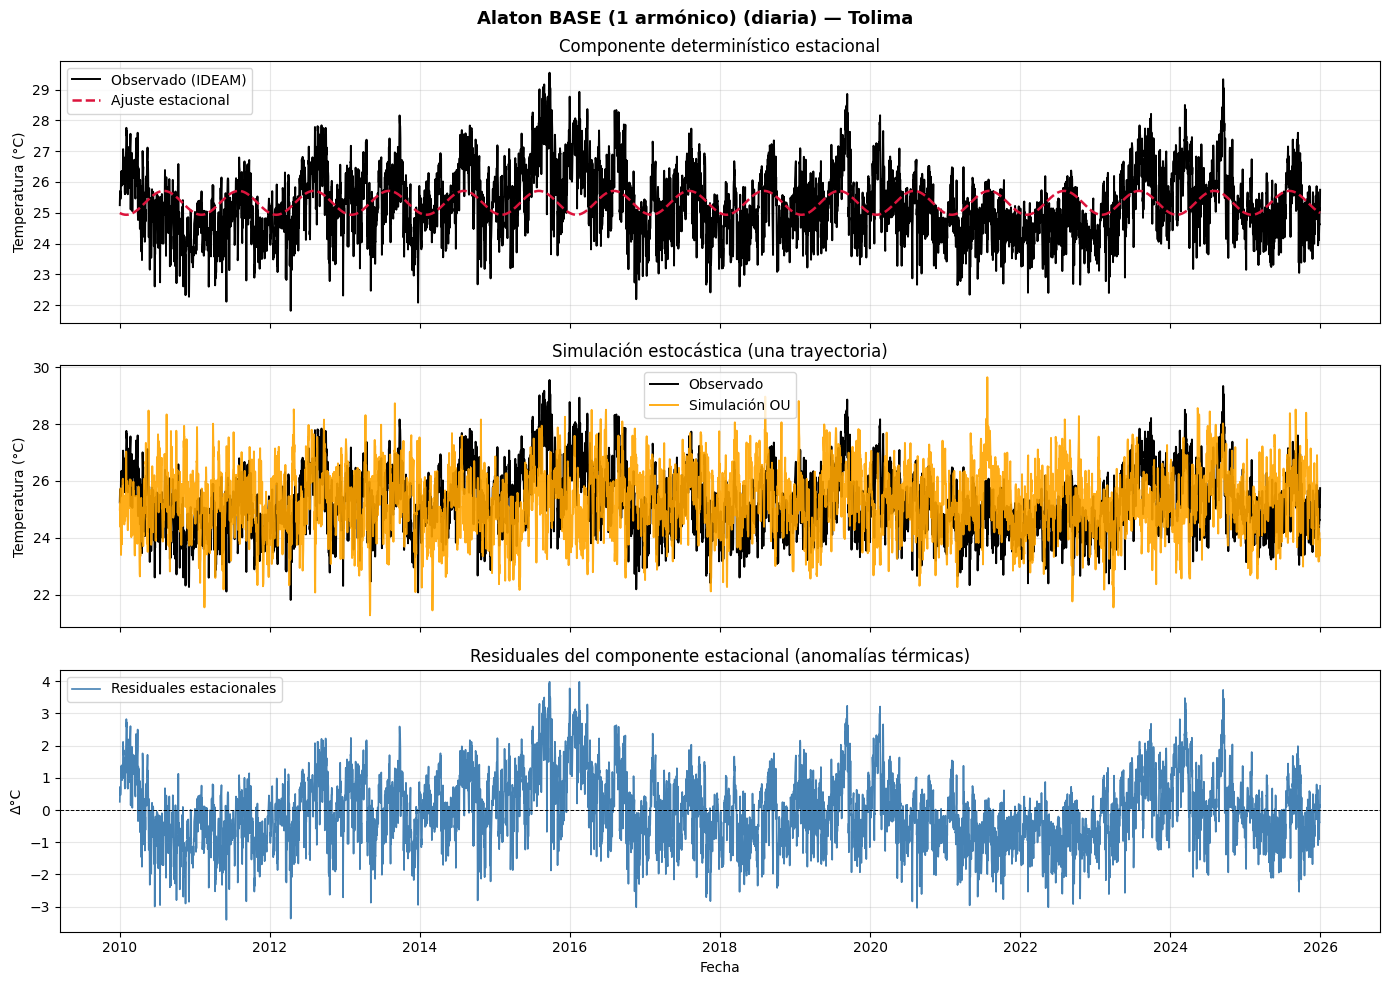


  ALATON BASE (1 armónico) | CASANARE | Salida: DIARIA

  ADF sobre residuales estacionales: stat=-7.250, p=1.790e-10

  Parámetros calibrados:
    φ (AR coef.)      = 0.69190
    κ (rev. a media)  = 0.36831
    σ (vol. AR(1))    = 0.66820
    α (intercepto)    = 0.000063  (esperado ≈ 0)


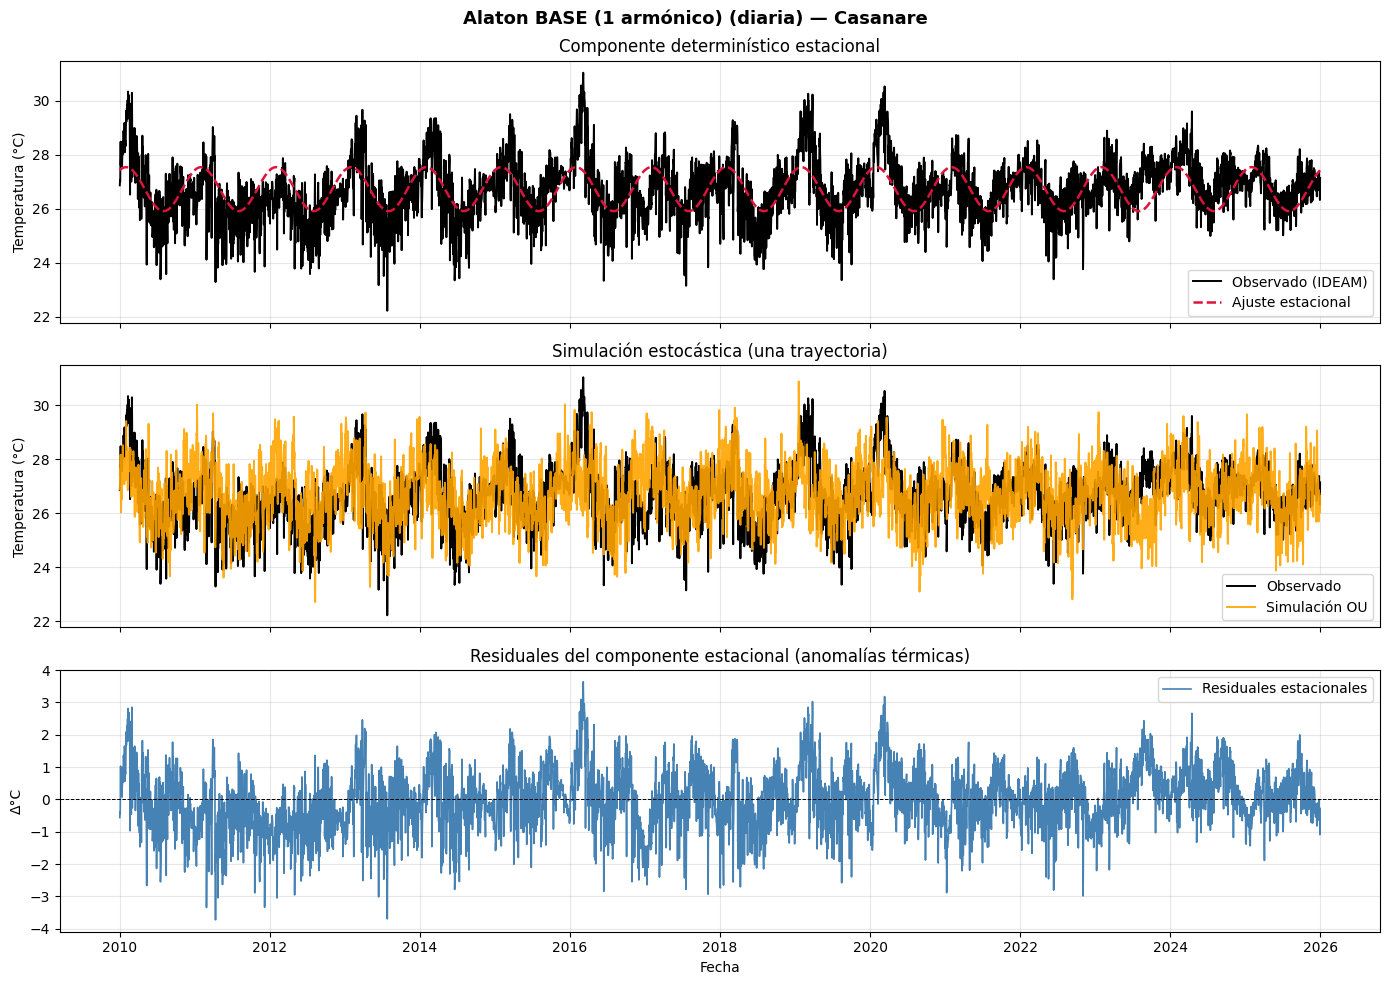


--- Coeficientes OLS Tolima (base) ---
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         25.3220      0.014   1796.634      0.000      25.294      25.350
sin           -0.2067      0.020    -10.368      0.000      -0.246      -0.168
cos           -0.3282      0.020    -16.471      0.000      -0.367      -0.289

--- Coeficientes OLS Casanare (base) ---
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         26.7236      0.012   2207.264      0.000      26.700      26.747
sin            0.4213      0.017     24.600      0.000       0.388       0.455
cos            0.6976      0.017     40.759      0.000       0.664       0.731


In [4]:
df_agg_tol_base, p_tol_base, ols_tol_base = modelar_temperatura_alaton(df_Tolima,   'Tolima',   n_armonicos=1)
df_agg_cas_base, p_cas_base, ols_cas_base = modelar_temperatura_alaton(df_Casanare, 'Casanare', n_armonicos=1)

print("\n--- Coeficientes OLS Tolima (base) ---")
print(ols_tol_base.summary().tables[1])
print("\n--- Coeficientes OLS Casanare (base) ---")
print(ols_cas_base.summary().tables[1])

### Alaton modificado (2 armónicos) para capturar bimodalidad ZCIT


  ALATON MODIFICADO (2 armónicos) | TOLIMA | Salida: DIARIA

  ADF sobre residuales estacionales: stat=-6.438, p=1.635e-08

  Parámetros calibrados:
    φ (AR coef.)      = 0.71242
    κ (rev. a media)  = 0.33909
    σ (vol. AR(1))    = 0.71944
    α (intercepto)    = 0.000046  (esperado ≈ 0)


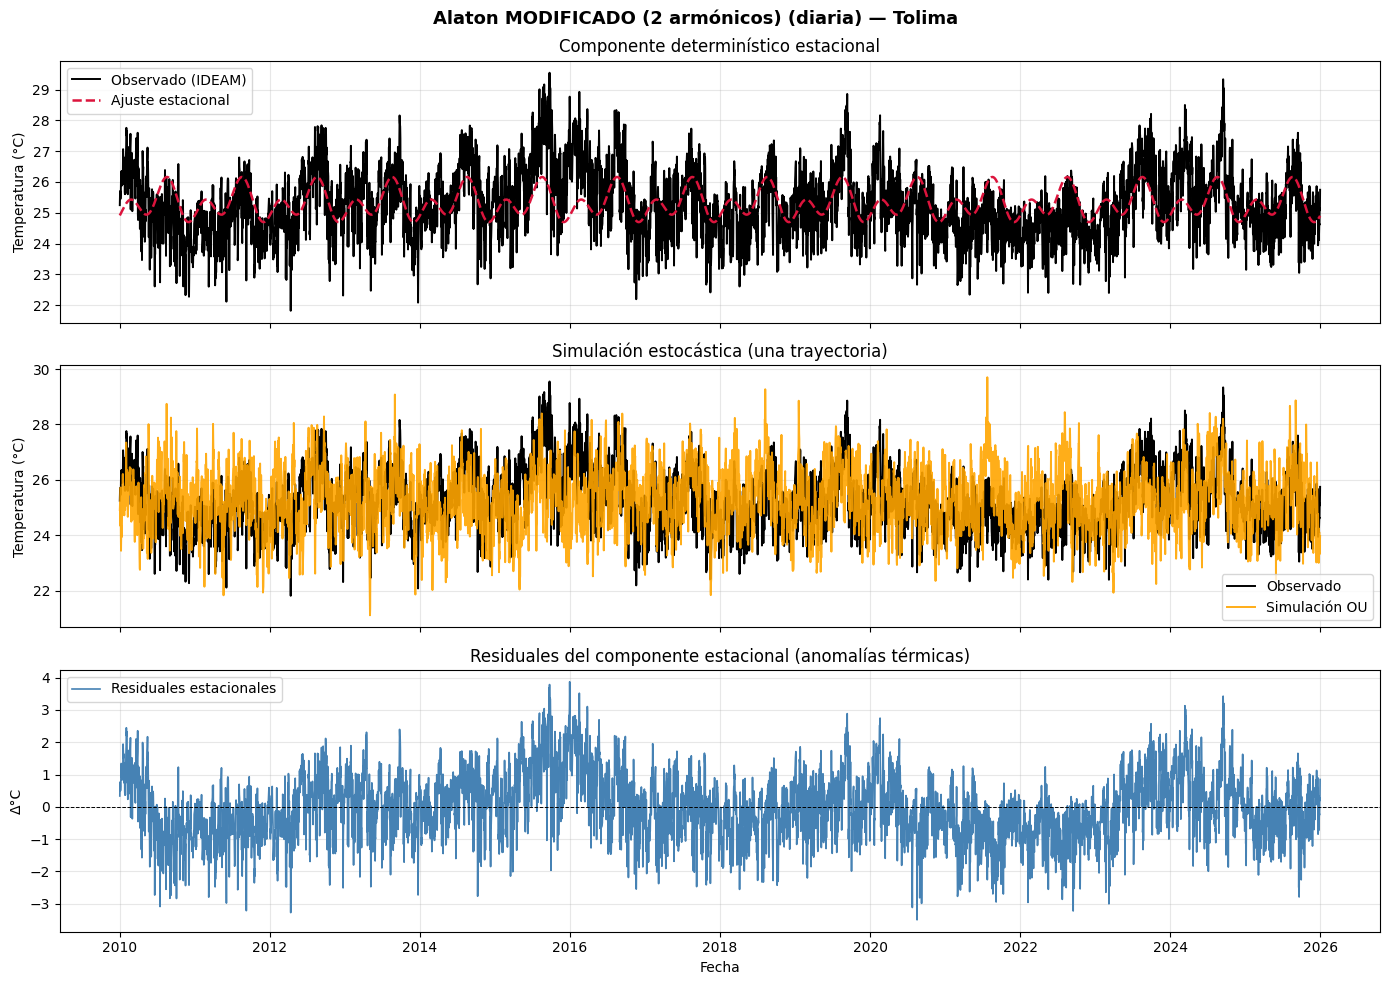


  ALATON MODIFICADO (2 armónicos) | CASANARE | Salida: DIARIA

  ADF sobre residuales estacionales: stat=-7.693, p=1.404e-11

  Parámetros calibrados:
    φ (AR coef.)      = 0.64166
    κ (rev. a media)  = 0.44370
    σ (vol. AR(1))    = 0.65812
    α (intercepto)    = 0.000040  (esperado ≈ 0)


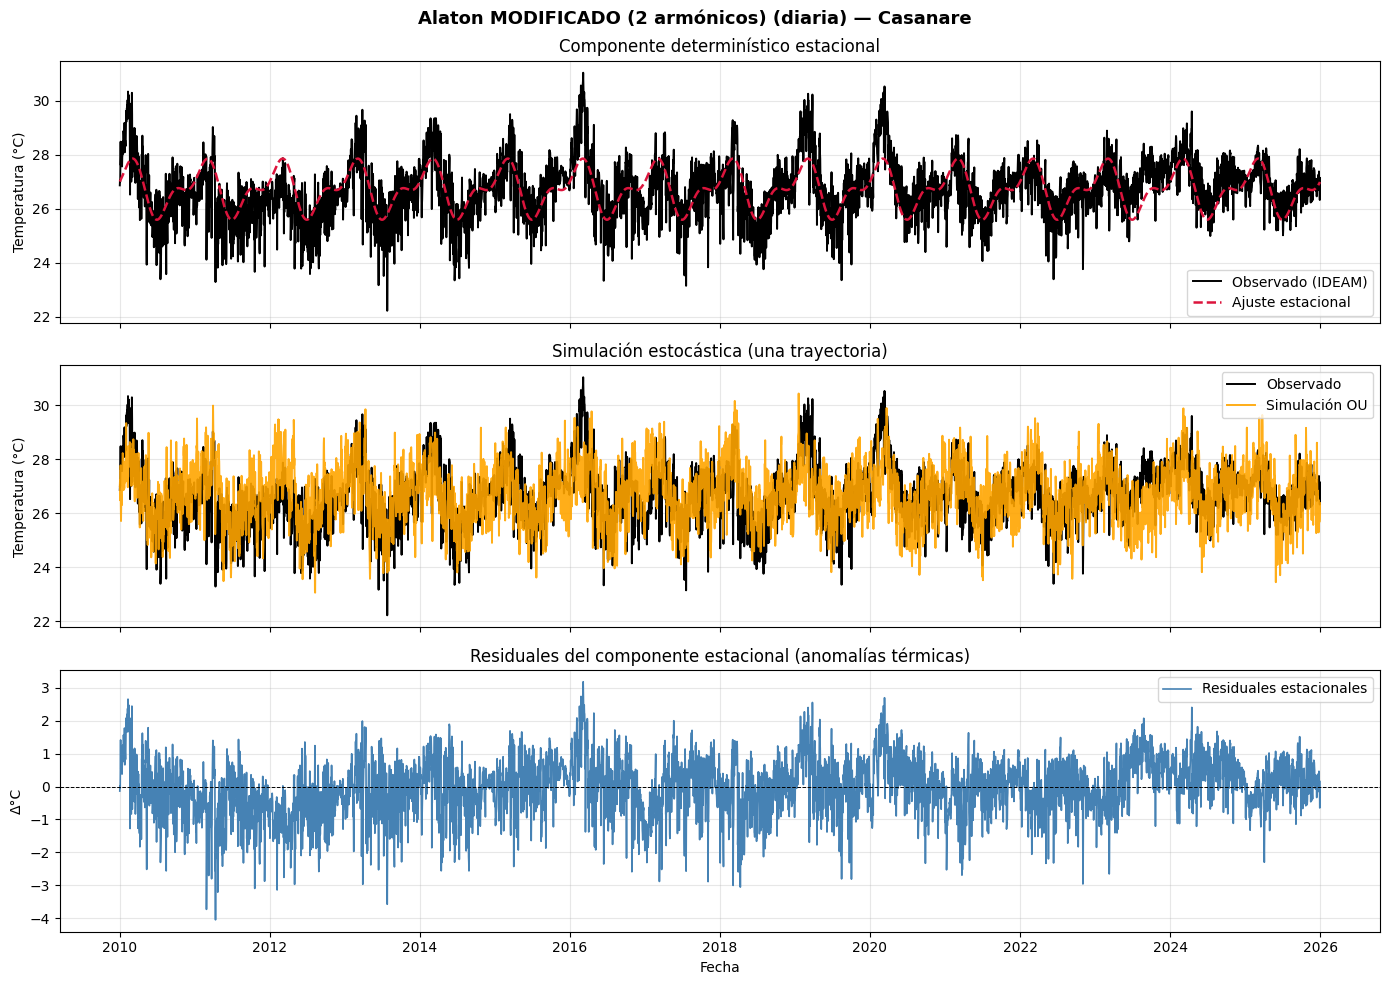


--- Coeficientes OLS Tolima (2do armónico) ---
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         25.3220      0.013   1887.928      0.000      25.296      25.348
sin           -0.2067      0.019    -10.895      0.000      -0.244      -0.170
cos           -0.3281      0.019    -17.302      0.000      -0.365      -0.291
sin2           0.4593      0.019     24.204      0.000       0.422       0.496
cos2          -0.0945      0.019     -4.985      0.000      -0.132      -0.057

--- Coeficientes OLS Casanare (2do armónico) ---
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         26.7239      0.011   2380.475      0.000      26.702      26.746
sin            0.4214      0.016     26.531      0.000       0.390       0.452
cos            0.6982      0.016 

In [5]:
df_agg_tol_mod, p_tol_mod, ols_tol_mod = modelar_temperatura_alaton(df_Tolima,   'Tolima',   n_armonicos=2)
df_agg_cas_mod, p_cas_mod, ols_cas_mod = modelar_temperatura_alaton(df_Casanare, 'Casanare', n_armonicos=2)

print("\n--- Coeficientes OLS Tolima (2do armónico) ---")
print(ols_tol_mod.summary().tables[1])
print("\n--- Coeficientes OLS Casanare (2do armónico) ---")
print(ols_cas_mod.summary().tables[1])

## Validación out-of-sample: Base vs. 2.° armónico

Se divide la muestra en 80% entrenamiento / 20% prueba. Se compara el ajuste **del componente estacional** (determinístico) de ambos modelos sobre el período de prueba.

> La trayectoria estocástica (OU) es aleatoria y no comparable contra datos reales, por lo que el benchmark se enfoca en la especificación del seasonal fit, que es la parte que se exporta al notebook de valoración (MC).

Métricas reportadas:
- **RMSE** — raíz del error cuadrático medio (°C)
- **MAE** — error absoluto medio (°C)
- **MASE** — MAE escalado por el MAE del predictor naïve (diferencia de un paso); MASE < 1 indica que el modelo supera la diferencia ingenua


[OOS] Tolima — Base vs. 2do Armónico (train=80%)
  Métrica  Alaton Base  Alaton 2do Armónico  Mejora %
RMSE (°C)       1.0457               0.9937      4.97
 MAE (°C)       0.8226               0.7879      4.22
     MASE       1.3582               1.3008      4.23


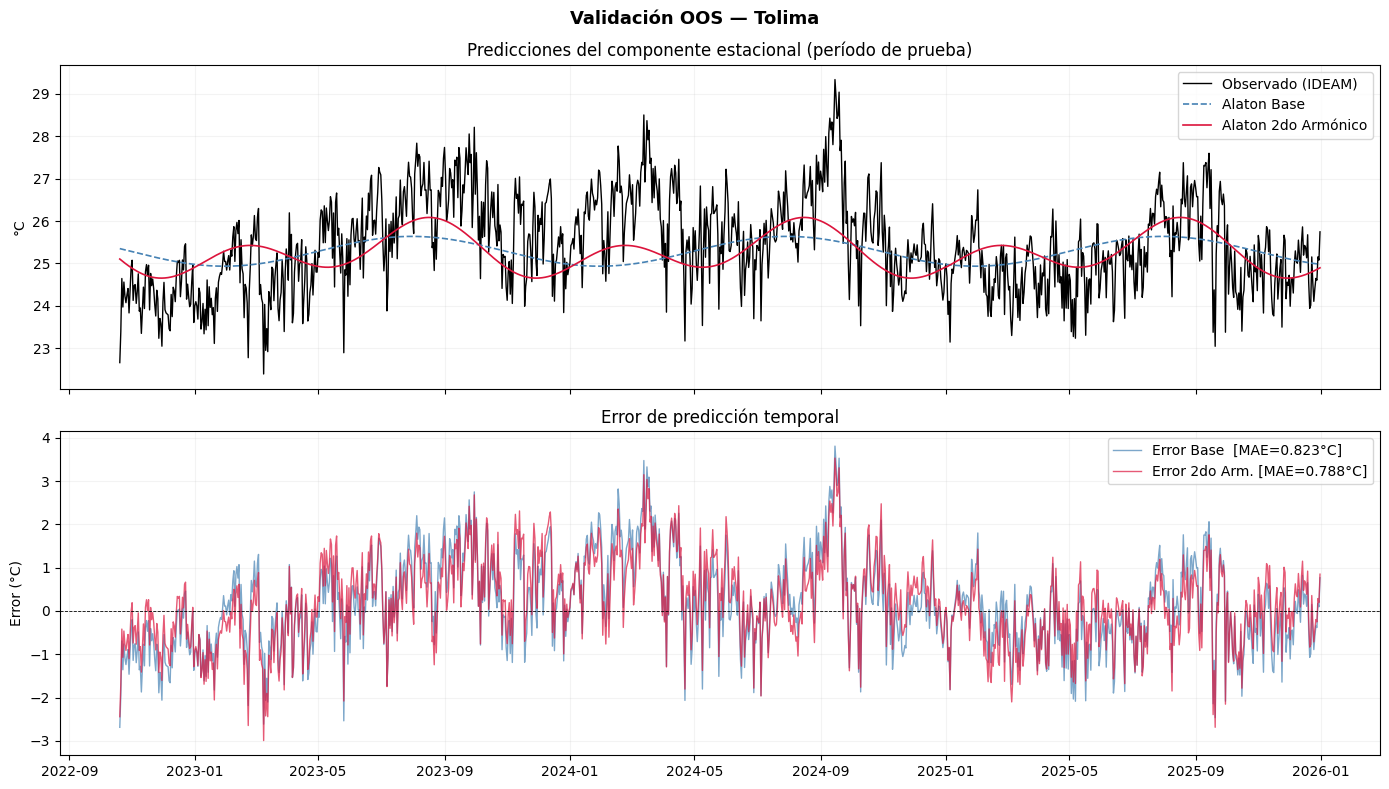


[OOS] Casanare — Base vs. 2do Armónico (train=80%)
  Métrica  Alaton Base  Alaton 2do Armónico  Mejora %
RMSE (°C)       0.8577               0.8018      6.52
 MAE (°C)       0.6902               0.6650      3.65
     MASE       1.2093               1.1653      3.64


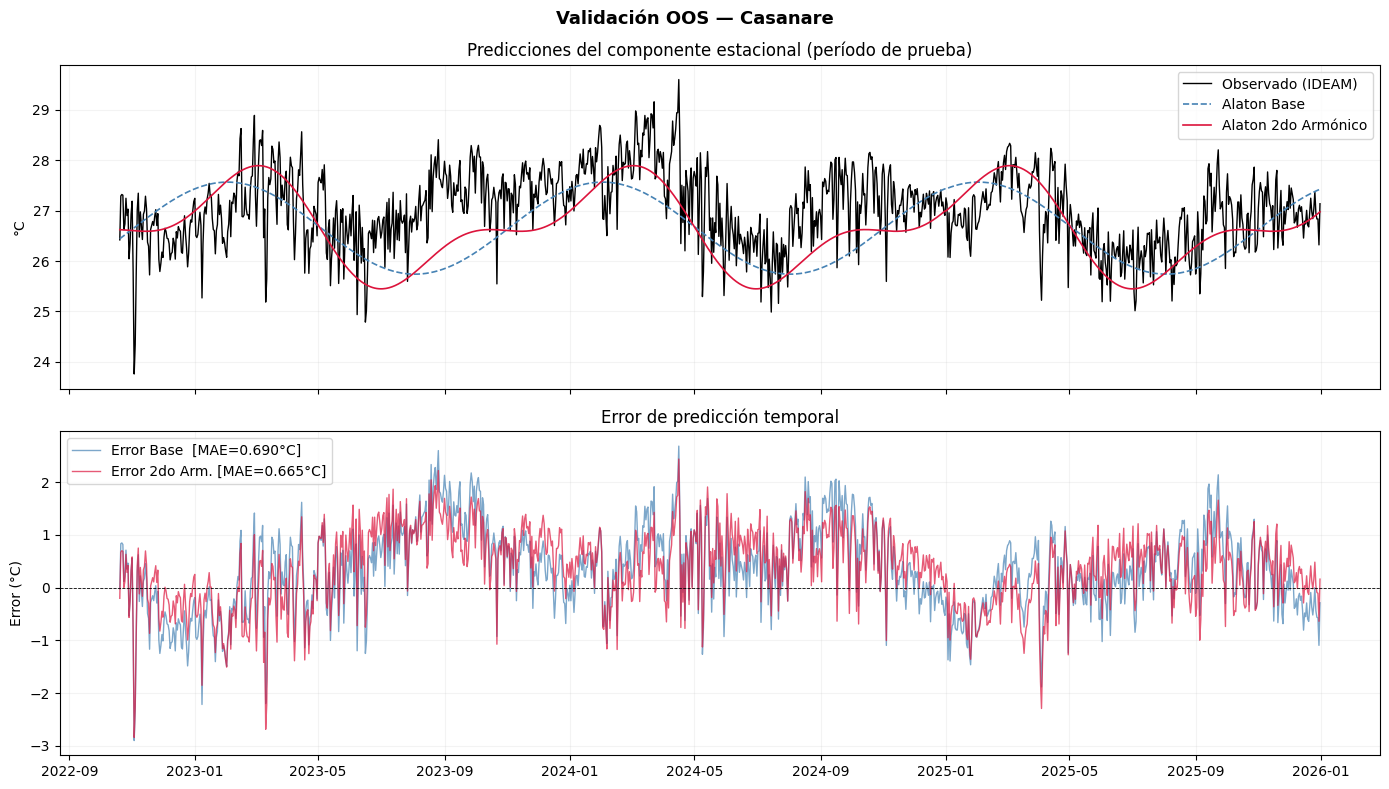

In [6]:
def comparar_alaton_oos(df_dpto, nombre_dpto, split_ratio=0.80):
    """
    Benchmarking out-of-sample del componente estacional:
    Alaton base (1 armónico) vs. modificado (2 armónicos).
    """
    temp = df_dpto.copy()
    d    = temp.index.dayofyear

    X_base = sm.add_constant(pd.DataFrame({
        'sin':  np.sin(2 * np.pi * d / 365),
        'cos':  np.cos(2 * np.pi * d / 365),
    }, index=temp.index))

    X_mod = sm.add_constant(pd.DataFrame({
        'sin':  np.sin(2 * np.pi * d / 365),
        'cos':  np.cos(2 * np.pi * d / 365),
        'sin2': np.sin(4 * np.pi * d / 365),
        'cos2': np.cos(4 * np.pi * d / 365),
    }, index=temp.index))

    split_idx = int(len(temp) * split_ratio)

    def _fit_and_predict(X):
        X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
        y_train = temp['t_mean'].iloc[:split_idx]
        m = sm.OLS(y_train, X_train).fit()
        return m.predict(X_test)

    preds_base = _fit_and_predict(X_base)
    preds_mod  = _fit_and_predict(X_mod)
    actuals    = temp['t_mean'].iloc[split_idx:]
    y_train    = temp['t_mean'].iloc[:split_idx]

    def rmse(y, yh): return np.sqrt(np.mean((y - yh) ** 2))
    def mae(y, yh):  return np.mean(np.abs(y - yh))
    def mase(y, yh, ytrain):
        naive = np.mean(np.abs(np.diff(ytrain)))
        return mae(y, yh) / naive if naive > 0 else np.nan

    a, pb, pm = actuals.values, preds_base.values, preds_mod.values
    metrics = {
        'RMSE_Base': rmse(a, pb), 'RMSE_Mod': rmse(a, pm),
        'MAE_Base':  mae(a, pb),  'MAE_Mod':  mae(a, pm),
        'MASE_Base': mase(a, pb, y_train.values),
        'MASE_Mod':  mase(a, pm, y_train.values),
    }

    comp_df = pd.DataFrame({
        'Métrica':            ['RMSE (°C)', 'MAE (°C)', 'MASE'],
        'Alaton Base':        [metrics['RMSE_Base'], metrics['MAE_Base'], metrics['MASE_Base']],
        'Alaton 2do Armónico':[metrics['RMSE_Mod'],  metrics['MAE_Mod'],  metrics['MASE_Mod']],
    }).round(4)
    comp_df['Mejora %'] = (
        100 * (comp_df['Alaton Base'] - comp_df['Alaton 2do Armónico']) / comp_df['Alaton Base']
    ).round(2)

    print(f"\n[OOS] {nombre_dpto} — Base vs. 2do Armónico (train={split_ratio*100:.0f}%)")
    print(comp_df.to_string(index=False))

    # Gráfica
    idx_test = actuals.index
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    fig.suptitle(f'Validación OOS — {nombre_dpto}', fontsize=13, fontweight='bold')

    axes[0].plot(idx_test, a,  color='black',    lw=1.0, label='Observado (IDEAM)')
    axes[0].plot(idx_test, pb, color='steelblue', lw=1.2, ls='--', label='Alaton Base')
    axes[0].plot(idx_test, pm, color='crimson',   lw=1.2, label='Alaton 2do Armónico')
    axes[0].set_title('Predicciones del componente estacional (período de prueba)')
    axes[0].set_ylabel('°C'); axes[0].legend(); axes[0].grid(alpha=0.15)

    axes[1].plot(idx_test, a - pb, color='steelblue', alpha=0.7, lw=1.0,
                 label=f'Error Base  [MAE={metrics["MAE_Base"]:.3f}°C]')
    axes[1].plot(idx_test, a - pm, color='crimson',   alpha=0.7, lw=1.0,
                 label=f'Error 2do Arm. [MAE={metrics["MAE_Mod"]:.3f}°C]')
    axes[1].axhline(0, color='black', ls='--', lw=0.6)
    axes[1].set_title('Error de predicción temporal')
    axes[1].set_ylabel('Error (°C)'); axes[1].legend(); axes[1].grid(alpha=0.15)

    plt.tight_layout()
    plt.show()

    return metrics, comp_df


metrics_tol, tabla_tol = comparar_alaton_oos(df_Tolima,   'Tolima')
metrics_cas, tabla_cas = comparar_alaton_oos(df_Casanare, 'Casanare')

## Decisión final y exportación de parámetros

Con base en la comparación OOS:
- **Tolima** → Alaton **Base (1 armónico)**
- **Casanare** → Alaton **2.° Armónico**

Se exportan los parámetros del modelo elegido para cada departamento a `data/processed/params_alaton.json`,
para ser consumidos por los notebooks 03 (validación de residuales) y 06 (simulación Monte Carlo).

In [7]:
# Parámetros del modelo elegido por departamento
params_alaton = {
    'Tolima':   p_tol_base,   # 1 armónico
    'Casanare': p_cas_mod,    # 2 armónicos
}

out_path = OUT_DIR / 'params_alaton.json'
with open(out_path, 'w') as f:
    json.dump(params_alaton, f, indent=2, ensure_ascii=False)

print(f"Parámetros Alaton exportados a: {out_path}")
print(json.dumps(params_alaton, indent=2, ensure_ascii=False))

Parámetros Alaton exportados a: ..\data\processed\params_alaton.json
{
  "Tolima": {
    "phi": 0.7395934748540848,
    "kappa": 0.30165460204177347,
    "sigma": 0.7252035502665275,
    "alpha": 5.1310666432435924e-05,
    "n_armonicos": 1,
    "ols_coefs": {
      "const": 25.321979804352125,
      "sin": -0.2067249253823492,
      "cos": -0.32819084730388015
    },
    "adf_p": 6.095978726368872e-11,
    "frecuencia_salida": "diaria"
  },
  "Casanare": {
    "phi": 0.6416598934283338,
    "kappa": 0.443696876680177,
    "sigma": 0.6581195304695222,
    "alpha": 4.024207512001986e-05,
    "n_armonicos": 2,
    "ols_coefs": {
      "const": 26.723880866667738,
      "sin": 0.4213585250116108,
      "cos": 0.6982228206049996,
      "sin2": 0.226695960439934,
      "cos2": -0.43488654884036454
    },
    "adf_p": 1.4042708981967234e-11,
    "frecuencia_salida": "diaria"
  }
}
